# 06 — Poincaré Sections and Route to Chaos

Stroboscopic Poincaré bifurcation diagrams; visualize the strange attractor; compute the maximal Lyapunov exponent.

In [10]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from steering.params import ModelParams, ForcingParams
from steering.models import (
    DuffingModel,
    BesselSteeringModel,
    ContinuousPFLModel,
    DiscretePFLModel,
    FullCircuitModel,
)
from steering.dynamics import VelocityDynamics, AccelerationDynamics
from steering.integrator import Simulation
from steering.visualization.style import use_paper_style

use_paper_style()


In [ ]:
from steering.analysis.poincare import bifurcation_diagram_poincare
from steering.analysis.lyapunov import max_lyapunov_exponent

bessel = BesselSteeringModel()
p = ModelParams(kappa_h=1.0, kappa_g=1.0, delta=1.49)
c1, c3 = bessel.taylor_coefficients(p)
gamma, omega = 0.1, np.sqrt(c1) 


## Bifurcation diagram: stroboscopic $\theta$ vs $F$

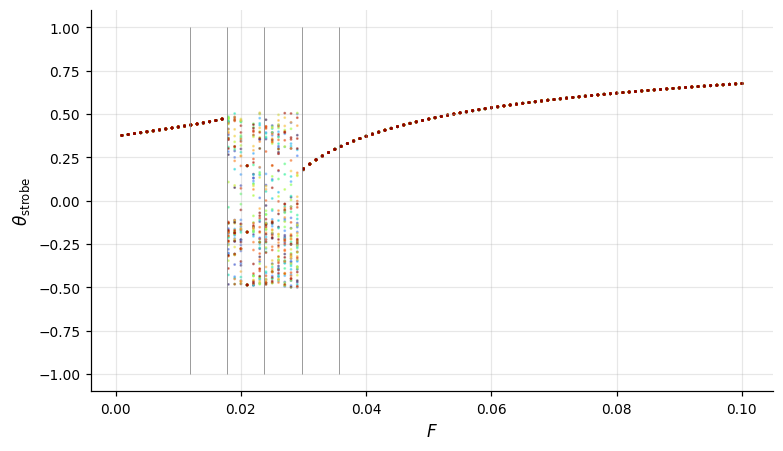

In [62]:
duffing = DuffingModel(c1=c1, c3=c3)
dyn = AccelerationDynamics(model=duffing, gamma=gamma)
F_vals = np.linspace(0.001, 0.1, 100)
diag_duffing = bifurcation_diagram_poincare(
    dyn, duffing, p, gamma=gamma, omega=omega,
    sweep_param='F', sweep_values=F_vals,
    state0=np.array([0.01, 0.0]),
    n_periods_transient=20, n_periods_record=60,
)
fig, ax = plt.subplots(figsize=(8, 4.5))
for v, vals in zip(diag_duffing['sweep_values'], diag_duffing['thetas']):
    ax.scatter(np.full_like(vals, v), vals, s=0.7, alpha=0.5, c = np.arange(len(vals)), cmap='turbo')
theoretical_F = melnikov_critical_forcing(c1, c3, gamma, omega)
ax.vlines([theoretical_F, 1.5 * theoretical_F, 2 * theoretical_F, 2.5 * theoretical_F, 3 * theoretical_F], -1, 1, color='gray', lw=0.5)
ax.set_xlabel(r'$F$'); ax.set_ylabel(r'$\theta_{\mathrm{strobe}}$')
plt.show()



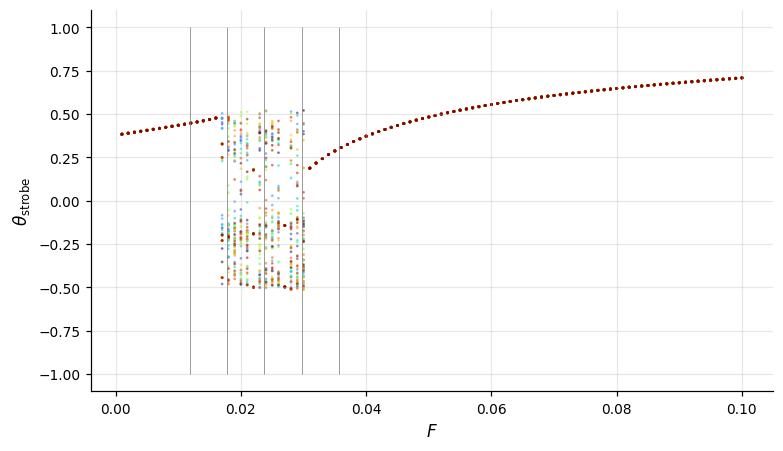

In [64]:
dyn = AccelerationDynamics(model=bessel, gamma=gamma)
F_vals = np.linspace(0.001, 0.1, 100)
diag_bessel = bifurcation_diagram_poincare(
    dyn, bessel, p, gamma=gamma, omega=omega,
    sweep_param='F', sweep_values=F_vals,
    state0=np.array([0.01, 0.0]),
    n_periods_transient=20, n_periods_record=60,
)
fig, ax = plt.subplots(figsize=(8, 4.5))
for v, vals in zip(diag_bessel['sweep_values'], diag_bessel['thetas']):
    ax.scatter(np.full_like(vals, v), vals, s=0.7, alpha=0.5, c = np.arange(len(vals)), cmap='turbo')
theoretical_F = melnikov_critical_forcing(c1, c3, gamma, omega)
ax.vlines([theoretical_F, 1.5 * theoretical_F, 2 * theoretical_F, 2.5 * theoretical_F, 3 * theoretical_F], -1, 1, color='gray', lw=0.5)
ax.set_xlabel(r'$F$'); ax.set_ylabel(r'$\theta_{\mathrm{strobe}}$')
plt.show()



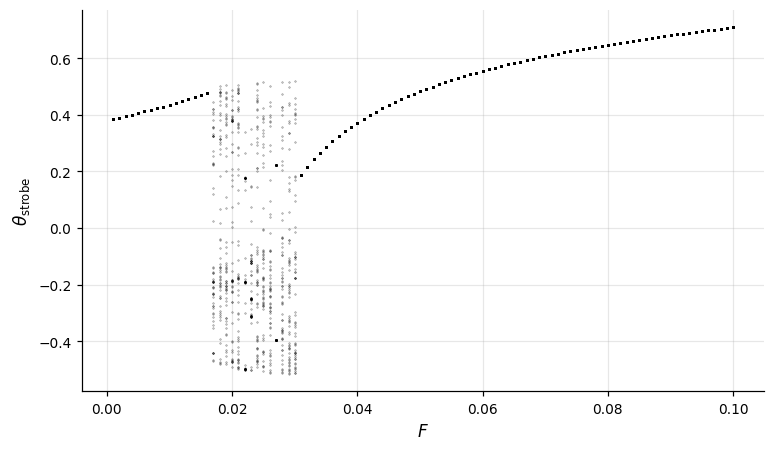

In [ ]:
neural = DiscretePFLModel(N_default=12)
dyn = AccelerationDynamics(model=neural, gamma=gamma)
F_vals = np.linspace(0.001, 0.1, 100)
diag = bifurcation_diagram_poincare(
    dyn, neural, p, gamma=gamma, omega=omega,
    sweep_param='F', sweep_values=F_vals,
    state0=np.array([0.01, 0.0]),
    n_periods_transient=20, n_periods_record=60,
)
fig, ax = plt.subplots(figsize=(8, 4.5))
for v, vals in zip(diag['sweep_values'], diag['thetas']):
    ax.plot(np.full_like(vals, v), vals, 'k.', ms=0.7, alpha=0.5)
ax.set_xlabel(r'$F$'); ax.set_ylabel(r'$\theta_{\mathrm{strobe}}$')
plt.show()



In [38]:
diag_pfl3_12 = diag.copy()

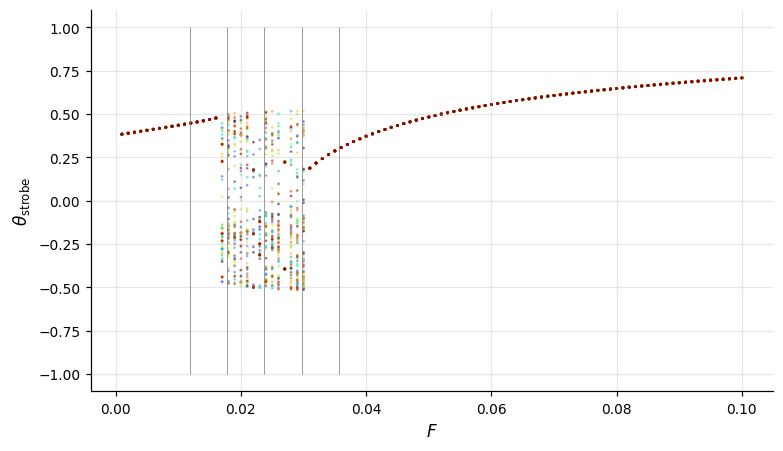

In [58]:
from steering.analysis.melnikov import melnikov_critical_forcing
fig, ax = plt.subplots(figsize=(8, 4.5))
for v, vals in zip(diag_pfl3_12['sweep_values'], diag_pfl3_12['thetas']):
    ax.scatter(np.full_like(vals, v), vals, s=0.7, alpha=0.5, c = np.arange(len(vals)), cmap='turbo')
theoretical_F = melnikov_critical_forcing(c1, c3, gamma, omega)
ax.vlines([theoretical_F, 1.5 * theoretical_F, 2 * theoretical_F, 2.5 * theoretical_F, 3 * theoretical_F], -1, 1, color='gray', lw=0.5)
ax.set_xlabel(r'$F$'); ax.set_ylabel(r'$\theta_{\mathrm{strobe}}$')
plt.show()


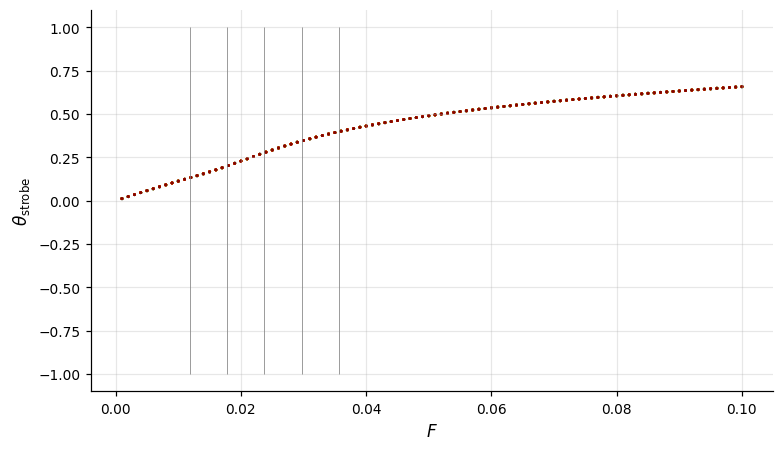

In [70]:
neural = DiscretePFLModel(N_default=6)
dyn = AccelerationDynamics(model=neural, gamma=gamma)
F_vals = np.linspace(0.001, 0.1, 100)
diag_pfl3_6 = bifurcation_diagram_poincare(
    dyn, neural, p, gamma=gamma, omega=omega,
    sweep_param='F', sweep_values=F_vals,
    state0=np.array([0.01, 0.0]),
    n_periods_transient=20, n_periods_record=60,
)
fig, ax = plt.subplots(figsize=(8, 4.5))
for v, vals in zip(diag_pfl3_6['sweep_values'], diag_pfl3_6['thetas']):
    ax.scatter(np.full_like(vals, v), vals, s=0.7, alpha=0.5, c = np.arange(len(vals)), cmap='turbo')
theoretical_F = melnikov_critical_forcing(c1, c3, gamma, omega)
ax.vlines([theoretical_F, 1.5 * theoretical_F, 2 * theoretical_F, 2.5 * theoretical_F, 3 * theoretical_F], -1, 1, color='gray', lw=0.5)
ax.set_xlabel(r'$F$'); ax.set_ylabel(r'$\theta_{\mathrm{strobe}}$')
plt.show()



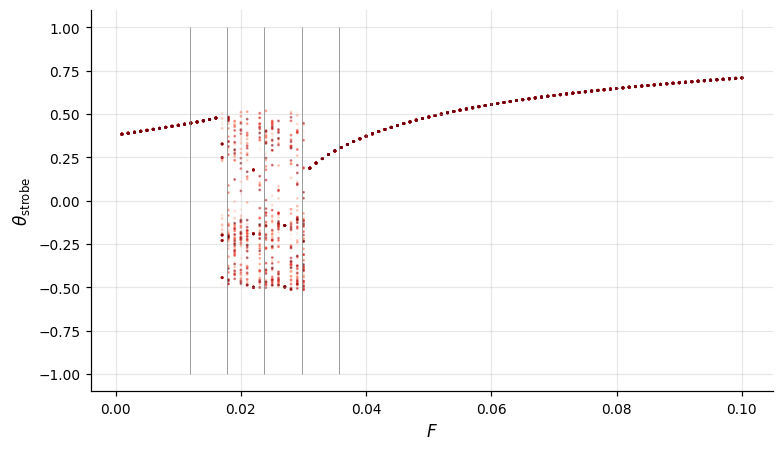

In [69]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for v, vals in zip(diag_pfl3_6['sweep_values'], diag_pfl3_6['thetas']):
    ax.scatter(np.full_like(vals, v), vals, s=0.7, alpha=0.5, c = np.arange(len(vals)), cmap='Reds')
theoretical_F = melnikov_critical_forcing(c1, c3, gamma, omega)
ax.vlines([theoretical_F, 1.5 * theoretical_F, 2 * theoretical_F, 2.5 * theoretical_F, 3 * theoretical_F], -1, 1, color='gray', lw=0.5)
ax.set_xlabel(r'$F$'); ax.set_ylabel(r'$\theta_{\mathrm{strobe}}$')
plt.show()


In [68]:
omega

0.42509170697473847

In [ ]:
neural.

In [ ]:
bessel = BesselSteeringModel()
p = ModelParams(kappa_h=1.0, kappa_g=1.0, delta=1.49)

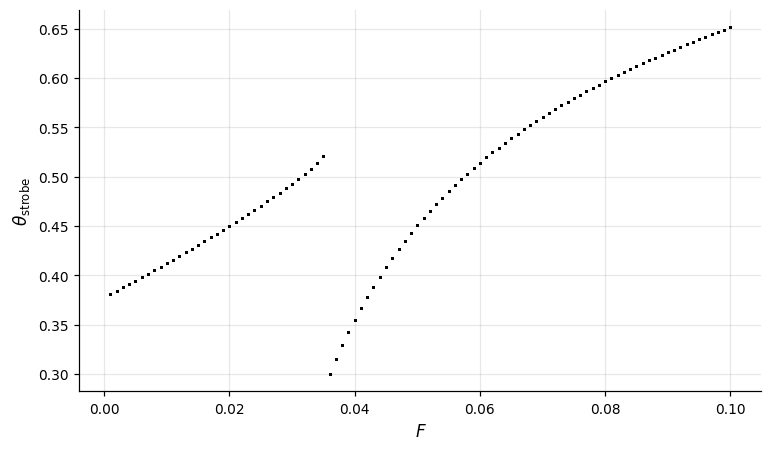

In [59]:
neural = FullCircuitModel()
p_neural = ModelParams(kappa_h=1.0, kappa_g=1.0, delta=1.49, N_neurons = 12, W_D3 = 0.001)
dyn = AccelerationDynamics(model=neural, gamma=gamma)
F_vals = np.linspace(0.001, 0.1, 100)
diag_fc = bifurcation_diagram_poincare(
    dyn, neural, p_neural, gamma=gamma, omega=omega,
    sweep_param='F', sweep_values=F_vals,
    state0=np.array([0.01, 0.0]),
    n_periods_transient=20, n_periods_record=60,
)
fig, ax = plt.subplots(figsize=(8, 4.5))
for v, vals in zip(diag_fc['sweep_values'], diag_fc['thetas']):
    ax.plot(np.full_like(vals, v), vals, 'k.', ms=0.7, alpha=0.5)
ax.set_xlabel(r'$F$'); ax.set_ylabel(r'$\theta_{\mathrm{strobe}}$')
plt.show()



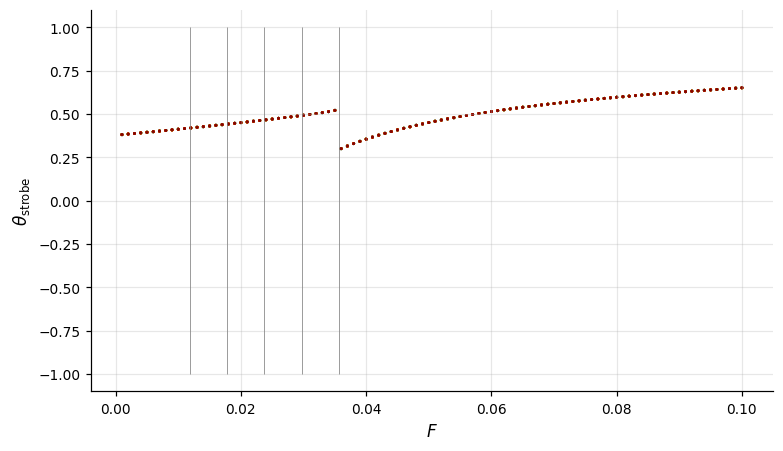

In [61]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for v, vals in zip(diag_fc['sweep_values'], diag_fc['thetas']):
    # ax.plot(np.full_like(vals, v), vals, 'k.', ms=0.7, alpha=0.5)
    ax.scatter(np.full_like(vals, v), vals, s=0.7, alpha=0.5, c = np.arange(len(vals)), cmap='turbo')
theoretical_F = melnikov_critical_forcing(c1, c3, gamma, omega)
ax.vlines([theoretical_F, 1.5 * theoretical_F, 2 * theoretical_F, 2.5 * theoretical_F, 3 * theoretical_F], -1, 1, color='gray', lw=0.5)
ax.set_xlabel(r'$F$'); ax.set_ylabel(r'$\theta_{\mathrm{strobe}}$')
plt.show()




## Lyapunov exponent across the same sweep

In [ ]:
F_lyap = np.linspace(0.05, 1.6, 12)
lambdas = []
for F in F_lyap:
    lam = max_lyapunov_exponent(
        dyn, p, gamma=gamma, F=F, omega=omega,
        state0=np.array([0.5, 0.0]),
        t_total=200.0, renorm_interval=1.0,
    )
    lambdas.append(lam)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(F_lyap, lambdas, 'o-')
ax.axhline(0, color='0.5', lw=0.5)
ax.set_xlabel(r'$F$'); ax.set_ylabel(r'$\lambda_{\max}$')
plt.show()
